In [1]:
import pandas as pd
import numpy as np
import string
from string import digits
import matplotlib.pyplot as plt
%matplotlib inline
import re
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from keras.layers import Input, LSTM, Embedding, Dense
from keras.models import Model
import codecs

In [2]:
!pip3 install torch torchvision torchaudio

In [3]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [4]:
from datasets import load_dataset

dataset = load_dataset("rahular/itihasa")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.03k [00:00<?, ?B/s]

itihasa.py:   0%|          | 0.00/4.89k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/2.61M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75162 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6149 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11722 [00:00<?, ? examples/s]

In [5]:
from datasets import load_dataset

dataset = load_dataset("rahular/itihasa", split="train")
dataset

Dataset({
    features: ['translation'],
    num_rows: 75162
})

In [6]:
import torch
from datasets import load_dataset

# Loading the Hugging Face dataset
dataset = load_dataset("rahular/itihasa")

# Extracting translations from the dataset
translations = dataset["train"]["translation"]

# Extracing Sanskrit and English sentences from each entry
sn_sentences = [entry["sn"] for entry in translations]
en_sentences = [entry["en"] for entry in translations]

half_dataset_size = len(sn_sentences) // 5
sn_sentences = sn_sentences[:half_dataset_size]
en_sentences = en_sentences[:half_dataset_size]


In [7]:
import pandas as pd
def read_sentences(file_path,num):
    sentences = []

    with open(file_path, 'r') as reader:
        for s in reader:
            if num==1:
                sentences.append(s.strip())
            else:
                sentences.append(codecs.unicode_escape_decode(s)[0].strip())

    return sentences

lines=pd.DataFrame()
lines['san']=sn_sentences
lines['eng']=en_sentences


In [8]:
# Lowercase all characters
lines.eng=lines.eng.apply(lambda x: x.lower())
lines.san=lines.san.apply(lambda x: x.lower())


In [9]:
import re

# Remove quotes
lines.eng=lines.eng.apply(lambda x: re.sub("'", '', x))
lines.san=lines.san.apply(lambda x: re.sub("'", '', x))

In [10]:
import string

exclude = set(string.punctuation) # Set of all special characters
# Remove all the special characters
lines.eng=lines.eng.apply(lambda x: ''.join(ch for ch in x if ch not in exclude))
lines.san=lines.san.apply(lambda x: ''.join(ch for ch in x if ch not in exclude))

In [11]:
from string import digits

# Remove all numbers from text
remove_digits = str.maketrans('', '', digits)
lines.eng=lines.eng.apply(lambda x: x.translate(remove_digits))
lines.san = lines.san.apply(lambda x: re.sub("[२३०८१५७९४६]", "", x))

In [12]:
# Remove extra spaces
lines.eng=lines.eng.apply(lambda x: x.strip())
lines.san=lines.san.apply(lambda x: x.strip())
lines.eng=lines.eng.apply(lambda x: re.sub(" +", " ", x))
lines.san=lines.san.apply(lambda x: re.sub(" +", " ", x))

In [13]:
# Add start and end tokens to target sequences
lines.eng = lines.eng.apply(lambda x : 'START_ '+ x + ' _END')

In [14]:
lines.sample(10)

,san,eng
3133,स संज्ञामुपलभ्यैव दीर्घमुष्णं च निःश्वसन्। कौस...,START_ having regained his senses he sighing h...
14262,सीदमानान्सुतान्दृष्ट्वा विह्वलान्स महाबलः। नना...,START_ beholding varuņas sors thus worn out an...
1692,मयोच्यमानं यदि ते श्रोतु छन्दो विलासिनि। श्रूय...,START_ if o dallianct loving damsel it is your...
7903,डिण्डिमं परिगृह्यान्या तथैवासक्तडिण्डिमा। प्रस...,START_ another woman was sleeping soundly embr...
12581,तां तु भिन्नां शिलां दृष्ट्वा सुग्रीवः क्रोधमु...,START_ beholding that crag thus severed sugrīv...
185,कश्चित्ररो वा नारी वा नाश्रीमान् नाप्यरूपवान्।...,START_ and no man and no woman was seen devoid...
13468,अभिवाद्य सुमित्रां च कैकेयीं च यशस्विनीम्। स म...,START_ thereupon saluting sumitrā famed kaikey...
2453,भरतश्च सशत्रुघ्नश्चीरवासा वनेचरः। वने वसन्तं क...,START_ bharata and śatrughna wearing ascetic c...
2854,अनुज्ञाय सुमन्त्रं च सबलं चैव तं गुहम्। आस्थाय...,START_ then telling sumantra guha and the forc...
1408,तदहं ते बलं दृष्ट्वा धनुषोऽप्यस्य पूरणे। द्वन्...,START_ then having witnessed your might in str...


In [15]:
all_eng_words=set()
for eng in lines.eng:
    for word in eng.split():
        if word not in all_eng_words:
            all_eng_words.add(word)

print(len(all_eng_words))

18402


In [16]:
all_san_words=set()
for san in lines.san:
    for word in san.split():
        if word not in all_san_words:
            all_san_words.add(word)

print(len(all_san_words))

72422


In [17]:
import numpy as np

# Max Length of source sequence
lenght_list=[]
for l in lines.san:
    lenght_list.append(len(l.split(' ')))
max_length_src = np.max(lenght_list)

mean_length_src=np.mean(lenght_list)

print(mean_length_src)

11.611029803086748


In [18]:
# Max Length of target sequence
lenght_list=[]
for l in lines.eng:
    lenght_list.append(len(l.split(' ')))
max_length_tar = np.max(lenght_list)

mean_length_tar=np.mean(lenght_list)

print(mean_length_tar)

31.660989888238426


In [19]:
# Sort the list of unique words in both English and Sanskrit
target_words = sorted(list(all_eng_words))
input_words = sorted(list(all_san_words))

# Calculate the number of unique tokens in each language
num_decoder_tokens = len(all_eng_words)
num_encoder_tokens = len(all_san_words)

num_encoder_tokens, num_decoder_tokens

(72422, 18402)

In [20]:
# Increment the number of decoder tokens by 1
num_decoder_tokens += 1

# Create dictionaries to map words to unique indices
input_token_index = dict([(word, i+1) for i, word in enumerate(input_words)])
target_token_index = dict([(word, i+1) for i, word in enumerate(target_words)])

# Create reverse dictionaries to map indices back to words
reverse_input_char_index = dict((i, word) for word, i in input_token_index.items())
reverse_target_char_index = dict((i, word) for word, i in target_token_index.items())


In [21]:
from sklearn.utils import shuffle

lines = shuffle(lines)
lines.head(10)

,san,eng
6146,दृश्यन्ते चास्य कर्माणि दुष्कराणि सुरैरपि। यान...,START_ his actions are such as are above the p...
5385,संरक्तनयनः श्रीमांस्तप्तकाञ्चनभूषणः। क्रोधेन म...,START_ highly exercised with ire that ranger o...
7960,तस्मादनिर्वेदकरं यत्नं चेष्टेऽहमुत्तमम्। अदृष्...,START_ therefore will i put forth fresh dear e...
7828,न त्वेव सीतां परमाभिजातां पथि स्थिते राजकुले प...,START_ but hanumān saw not sītā of the highest...
4850,आश्रमं तमुपागम्य राघवः सहलक्ष्मणः। कृत्वा पौर्...,START_ arriving at the asylum rāghava along wi...
2273,सा विद्धा बहुभिर्वाक्यैर्दिग्धैरिव गजाङ्गना। च...,START_ like to a sheelephant she being pierced...
12395,यत्तदाभिप्रसन्नेन सशरं कार्मुकं महत्। देवासुरव...,START_ do you beating hundreds of drums today ...
9778,दीप्तपावकसंकाशैः शितैः काञ्चनभूषणैः। न त्वामिच...,START_ i do not wish to behold you slain by th...
8876,ततस्तु रक्षोऽधिपतिर्महात्मा हनूमताक्षे निहते क...,START_ on prince akşa having been slain by han...
4534,अहमेवाहरिष्यामि सर्वांल्लोकान् महामुने। आवासं ...,START_ o mighty anchorite i shall acquire all ...


## **Train and Test Split**

In [22]:
from sklearn.model_selection import train_test_split

# Train - Test Split
X, y =  lines.san, lines.eng
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1)

# Get the number of samples in each split
X_train.shape, X_test.shape

((13528,), (1504,))

In [23]:
# Combine the corresponding Sanskrit (X) and English (y) sentences in DataFrames
train_df = pd.DataFrame({'san': X_train, 'eng': y_train})
test_df = pd.DataFrame({'san': X_test, 'eng': y_test})

# Save the DataFrames to pickle files
train_df.to_pickle('train_data.pkl')
test_df.to_pickle('test_data.pkl')

# Optional: Check if saved correctly
print(train_df.head())
print(test_df.head())

                                                     san  \
9042   हनूमांस्तु गुरून् वृद्धाञ्जाम्बवत्प्रमुखांस्तद...   
10712  ततो दृष्ट्वा सरुधिरं निषण्णं गाढमर्पितम्। भ्रा...   
13965  पुत्रद्वयं ममाप्यस्यां भार्यायां संबभूव ह॥ माय...   
5589   अशुभं वत मन्येऽहं गोमायुर्वाशते यथा। स्वस्ति स...   
10072  सुविभक्तमहाव्यूहा महावानररक्षिता। अनीकिनी सा व...   

                                                     eng  
9042   START_ and that mighty monkey hanumān saluted ...  
10712  START_ then seeing his brother having a distre...  
13965  START_ on this wife of mine i have also beget ...  
5589   START_ ah i consider this as inauspicious—that...  
10072  START_ that army being skilfully divided into ...  
                                                     san  \
7080   यत्र तिष्ठति धर्मज्ञस्तपसा स्वेन भावितः। मेरुस...   
14716  सोऽहं दृष्टबलस्तुभ्यमिच्छामि हरिपुङ्गव। त्वया ...   
5110   नानाशस्त्र प्रहरणाः खरप्रमुखराक्षसाः। तेन संजा...   
10672  तौ दृष्ट्वा भ्रातरौ तत्र प्रवीरौ पुरुष

In [24]:
import numpy as np

def generate_batch(X=X_train, y=y_train, batch_size=128):
    ''' Generate a batch of data '''
    while True:
        for j in range(0, len(X), batch_size):
            # Adjust batch size for the last batch if necessary
            current_batch_size = min(batch_size, len(X) - j)

            # Initialize the encoder, decoder inputs, and decoder target data
            encoder_input_data = np.zeros((current_batch_size, max_length_src), dtype='float32')
            decoder_input_data = np.zeros((current_batch_size, max_length_tar), dtype='float32')
            decoder_target_data = np.zeros((current_batch_size, max_length_tar, num_decoder_tokens), dtype='float32')

            # Populate the encoder, decoder input and target sequences
            for i, (input_text, target_text) in enumerate(zip(X[j:j + current_batch_size], y[j:j + current_batch_size])):
                # Populate encoder input data
                for t, word in enumerate(input_text.split()):
                    if word in input_token_index:  # Ensure word exists in the vocabulary
                        encoder_input_data[i, t] = input_token_index[word]

                # Populate decoder input and target data
                for t, word in enumerate(target_text.split()):
                    if word in target_token_index:
                        if t < len(target_text.split()) - 1:
                            decoder_input_data[i, t] = target_token_index[word]  # Decoder input sequence
                        if t > 0:
                            # One-hot encode the decoder target sequence
                            decoder_target_data[i, t - 1, target_token_index[word]] = 1.

            # Yield NumPy arrays instead of lists
            yield [np.array(encoder_input_data), np.array(decoder_input_data)], np.array(decoder_target_data)


In [25]:
latent_dim = 50

In [26]:
from keras.layers import Input, LSTM, Embedding, Dense

# Encoder
encoder_inputs = Input(shape=(None,))
enc_emb =  Embedding(num_encoder_tokens, latent_dim, mask_zero = True)(encoder_inputs)
encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
# We discard `encoder_outputs` and only keep the states.
encoder_states = [state_h, state_c]

In [27]:
# Set up the decoder, using `encoder_states` as initial state.
decoder_inputs = Input(shape=(None,))
dec_emb_layer = Embedding(num_decoder_tokens, latent_dim, mask_zero = True)
dec_emb = dec_emb_layer(decoder_inputs)
# We set up our decoder to return full output sequences,
# and to return internal states as well. We don't use the
# return states in the training model, but we will use them in inference.
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb,
                                     initial_state=encoder_states)
decoder_dense = Dense(num_decoder_tokens, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Define the model that will turn
# `encoder_input_data` & `decoder_input_data` into `decoder_target_data`
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

In [28]:
from keras.optimizers import Adam

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Display model architecture
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, None)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, None)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, None, 50)       │      3,621,100 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ not_equal (NotEqual)      │ (None, None)           │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_1 (Embedding)   │ (None, None, 50)       │        920,150 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ [(None, 50), (None,    │         20,200 │ embedding[0][0],       │
│                           │ 50), (None, 50)]       │                │ not_equal[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ [(None, None, 50),     │         20,200 │ embedding_1[0][0],     │
│                           │ (None, 50), (None,     │                │ lstm[0][1], lstm[0][2] │
│                           │ 50)]                   │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, None, 18403)    │        938,553 │ lstm_1[0][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 5,520,203 (21.06 MB)

 Trainable params: 5,520,203 (21.06 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
train_samples = len(X_train)
val_samples = len(X_test)
batch_size = 32
epochs = 5

In [30]:
# # Train the model
# history = model.fit(
#     generate_batch(X_train, y_train, batch_size=batch_size),
#     steps_per_epoch=train_samples // batch_size,
#     epochs=epochs,
#     validation_data=generate_batch(X_test, y_test, batch_size=batch_size),
#     validation_steps=val_samples // batch_size
# )


In [31]:
import tensorflow as tf
import numpy as np

def generate_batch(X, y, batch_size=128):
    ''' Generate a batch of data '''
    while True:
        for j in range(0, len(X), batch_size):
            current_batch_size = min(batch_size, len(X) - j)

            encoder_input_data = np.zeros((current_batch_size, max_length_src), dtype='float32')
            decoder_input_data = np.zeros((current_batch_size, max_length_tar), dtype='float32')
            decoder_target_data = np.zeros((current_batch_size, max_length_tar, num_decoder_tokens), dtype='float32')

            for i, (input_text, target_text) in enumerate(zip(X[j:j + current_batch_size], y[j:j + current_batch_size])):
                # Populate encoder input data
                for t, word in enumerate(input_text.split()):
                    if word in input_token_index:
                        encoder_input_data[i, t] = input_token_index[word]

                # Populate decoder input and target data
                for t, word in enumerate(target_text.split()):
                    if word in target_token_index:
                        if t < len(target_text.split()) - 1:
                            decoder_input_data[i, t] = target_token_index[word]
                        if t > 0:
                            decoder_target_data[i, t - 1, target_token_index[word]] = 1.

            yield (encoder_input_data, decoder_input_data), decoder_target_data

# Define the output signature of your dataset (this ensures TensorFlow understands the shape and type)
def create_tf_dataset(X, y, batch_size=128):
    output_signature = (
        (
            tf.TensorSpec(shape=(None, max_length_src), dtype=tf.float32),
            tf.TensorSpec(shape=(None, max_length_tar), dtype=tf.float32),
        ),
        tf.TensorSpec(shape=(None, max_length_tar, num_decoder_tokens), dtype=tf.float32)
    )

    dataset = tf.data.Dataset.from_generator(
        lambda: generate_batch(X, y, batch_size),
        output_signature=output_signature
    )

    return dataset


In [32]:
# Create datasets for training and validation
train_dataset = create_tf_dataset(X_train, y_train, batch_size=batch_size)
val_dataset = create_tf_dataset(X_test, y_test, batch_size=batch_size)

# Train the model
history = model.fit(
    train_dataset,
    steps_per_epoch=train_samples // batch_size,
    epochs=epochs,
    validation_data=val_dataset,
    validation_steps=val_samples // batch_size
)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 622s 1s/step - accuracy: 0.0035 - loss: 7.6518 - val_accuracy: 0.0039 - val_loss: 6.5362
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 614s 1s/step - accuracy: 0.0040 - loss: 6.4581 - val_accuracy: 0.0056 - val_loss: 6.3709
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 623s 1s/step - accuracy: 0.0057 - loss: 6.2600 - val_accuracy: 0.0068 - val_loss: 6.1963
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 617s 1s/step - accuracy: 0.0069 - loss: 6.0630 - val_accuracy: 0.0078 - val_loss: 6.0588
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 617s 1s/step - accuracy: 0.0080 - loss: 5.9017 - val_accuracy: 0.0087 - val_loss: 5.9520


In [33]:
# Corrected filename for saving weights
model.save_weights('nmt_model.weights.h5')


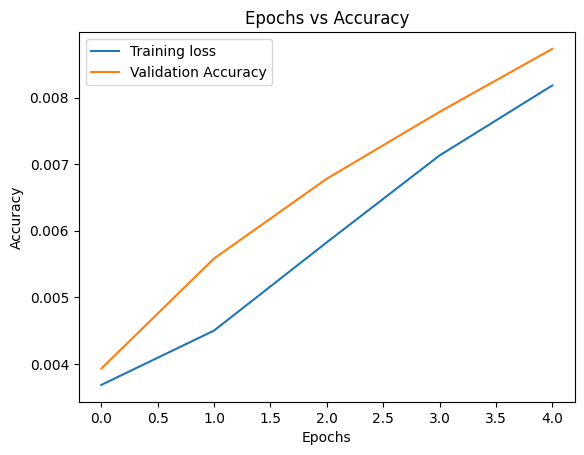

In [34]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(range(len(history.history['accuracy'])), history.history['accuracy'], label='Training loss')
plt.plot(range(len(history.history['val_accuracy'])), history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Epochs vs Accuracy")
plt.legend()
plt.show()


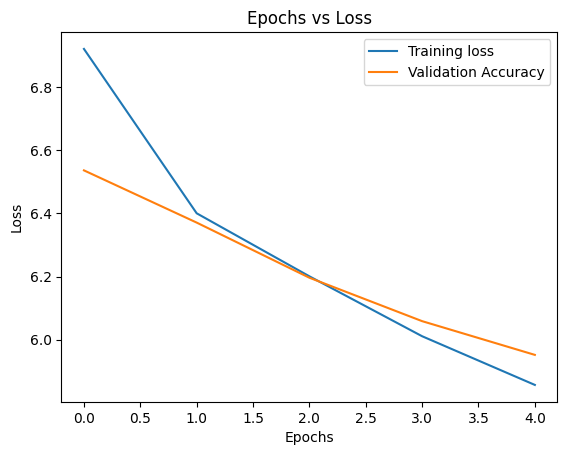

In [35]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(range(len(history.history['loss'])), history.history['loss'], label='Training loss')
plt.plot(range(len(history.history['val_loss'])), history.history['val_loss'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Epochs vs Loss")
plt.legend()
plt.show()


In [36]:
# Corrected filename for saving weights
model.save_weights('nmt_model.weights.h5')

In [37]:
# Encode the input sequence to get the "thought vectors"
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder setup
# Below tensors will hold the states of the previous time step
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

dec_emb2= dec_emb_layer(decoder_inputs) # Get the embeddings of the decoder sequence

# To predict the next word in the sequence, set the initial states to the states from the previous time step
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=decoder_states_inputs)
decoder_states2 = [state_h2, state_c2]
decoder_outputs2 = decoder_dense(decoder_outputs2) # A dense softmax layer to generate prob dist. over the target vocabulary

# Final decoder model
decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs2] + decoder_states2)

In [38]:
def decode_sequence(input_seq,lenn):
    # Encode the input as state vectors.
    states_value = encoder_model.predict(input_seq)
    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1,1))
    # Populate the first character of target sequence with the start character.
    target_seq[0, 0] = target_token_index['START_']

    # Sampling loop for a batch of sequences
    # (to simplify, here we assume a batch of size 1).
    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_char = reverse_target_char_index[sampled_token_index]
        decoded_sentence += ' '+sampled_char

        # Exit condition: either hit max length
        # or find stop character.
        if (sampled_char == '_END' or
           len(decoded_sentence) > lenn*(mean_length_tar/mean_length_src)):
            stop_condition = True

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index

        # Update states
        states_value = [h, c]

    return decoded_sentence

In [39]:
val_gen = generate_batch(X_test, y_test, batch_size = 1)
k=-1
res_out=np.array([['the sentence in engish','the sanskrit sentence','predicted translation']])

for k in range(1,2):

  (input_seq, actual_output), _ = next(val_gen)
  decoded_sentence = decode_sequence(input_seq,len(X_test[k-1:k].values[0]))
  res_out=np.append(res_out,np.array([[y_test[k-1:k].values[0][7:-5],X_test[k-1:k].values[0],decoded_sentence[1:-5]]]),axis=0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━

In [40]:
res_out

array([['the sentence in engish', 'the sanskrit sentence',
        'predicted translation'],
       ['there dwells there the righteous and famous merusāvarani sanctified by virtue of his own ascesticism and like to brahmā himself like to prajāpati dwelling by mahameru',
        'यत्र तिष्ठति धर्मज्ञस्तपसा स्वेन भावितः। मेरुसावर्णिरित्येष ख्यातो चै ब्रह्मणा समः॥ ।।',
        'and the king of the lord of the lord of the lord of the lord of the lord of the lord of the lord of the lord of the lord of the lord of the lord of the lord of the lord of the lord of the lord of the lord of the lord of the lord o']],
      dtype='<U230')

In [41]:

res_out = np.array(res_out)

original_english_sentences = res_out[1:, 0]  # Skip the header row
predicted_translations = res_out[1:, 2]

accurate_predictions = np.sum(original_english_sentences == predicted_translations)
total_predictions = len(predicted_translations)
accuracy = accurate_predictions / total_predictions

print(f"Accuracy: {accuracy*100:.2f}%")


Accuracy: 0.00%
